In [1]:
a = 3
print(a)

3


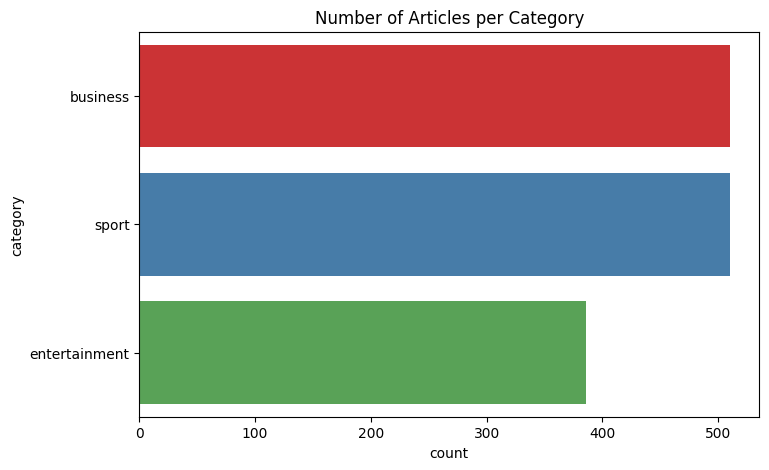

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(
    data=bbc_text,
    y="category",
    hue="category",
    palette="Set1",
    legend=False
)
plt.title("Number of Articles per Category")
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


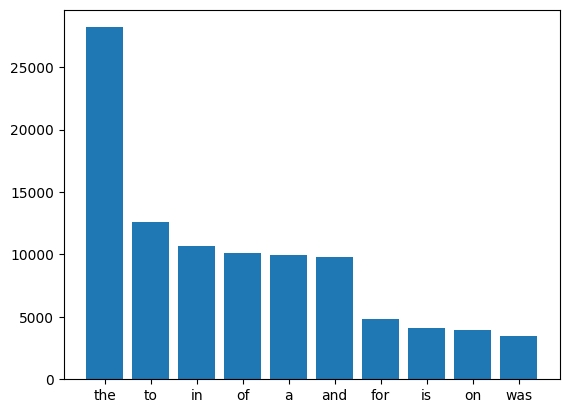

In [12]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

def plot_stopwords(data):
    stop=set(stopwords.words('english'))
    data_split= data.str.split()
    data_list=data_split.values.tolist()
    corpus=[word for i in data_list for word in i]
    from collections import defaultdict
    dictionary_stopwords=defaultdict(int)
    for word in corpus:
        if word in stop:
            dictionary_stopwords[word]+=1
            
    top=sorted(dictionary_stopwords.items(), key=lambda x:x[1],reverse=True)[:10] 
    x,y=zip(*top)
    plt.bar(x,y)
plot_stopwords(bbc_text['News_Headline'])

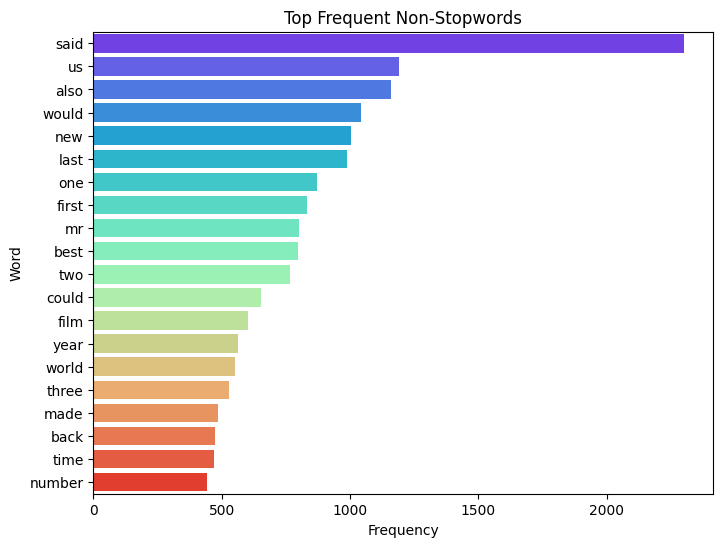

In [11]:
import pandas as pd
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

def top_frequent_words(data):
    stop = set(stopwords.words('english'))

    data_split = data.str.lower().str.split()
    data_list = data_split.values.tolist()
    corpus = [word for i in data_list for word in i]

    counter = Counter(corpus)
    most_common = counter.most_common()

    words, counts = [], []
    for word, count in most_common:
        if word not in stop and word.isalpha():
            words.append(word)
            counts.append(count)
        if len(words) == 20:
            break

    # Create DataFrame for seaborn
    plot_df = pd.DataFrame({
        "word": words,
        "count": counts
    })

    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=plot_df,
        x="count",
        y="word",
        hue="word",
        palette="rainbow",
        legend=False
    )
    plt.title("Top Frequent Non-Stopwords")
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.show()

top_frequent_words(bbc_text["News_Headline"])

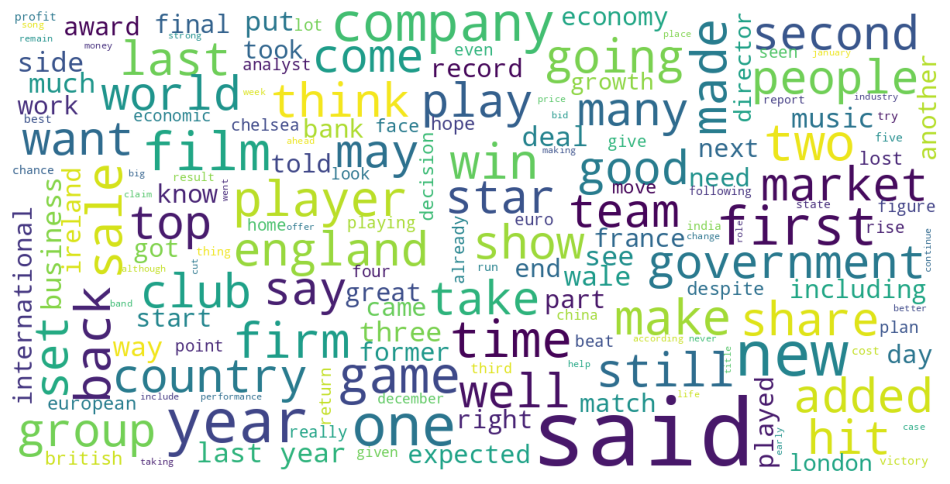

In [10]:
import os
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud, STOPWORDS

# Force NLTK data to live inside the repo (so it persists and is discoverable)
NLTK_DATA_DIR = os.path.join(os.getcwd(), "nltk_data")
os.makedirs(NLTK_DATA_DIR, exist_ok=True)

# Tell NLTK explicitly where to look
if NLTK_DATA_DIR not in nltk.data.path:
    nltk.data.path.insert(0, NLTK_DATA_DIR)


for pkg in ["stopwords", "wordnet", "punkt", "punkt_tab", "omw-1.4"]:
    try:
        nltk.download(pkg, download_dir=NLTK_DATA_DIR, quiet=True)
    except Exception as e:
        print(f"NLTK download warning for {pkg}: {e}")

# Use the tokenizer directly (avoids some wrapper edge-cases)
from nltk.tokenize import TreebankWordTokenizer
tokenizer = TreebankWordTokenizer()

def plot_wordcloud(data):
    stop = set(stopwords.words("english"))
    lemmatizer = WordNetLemmatizer()

    corpus = []
    for text in data:
        tokens = tokenizer.tokenize(str(text).lower())
        tokens = [
            lemmatizer.lemmatize(w)
            for w in tokens
            if w.isalpha() and w not in stop and len(w) > 2
        ]
        corpus.extend(tokens)

    wc = WordCloud(
        background_color="white",
        stopwords=STOPWORDS,
        max_words=200,
        max_font_size=40,
        scale=3,
        random_state=1
    ).generate(" ".join(corpus))

    plt.figure(figsize=(12, 12))
    plt.axis("off")
    plt.imshow(wc)
    plt.show()

# Run
plot_wordcloud(bbc_text["News_Headline"])

In [9]:
bbc_text = bbc_text.apply(lambda x: x.astype(str).str.lower())

In [14]:
bbc_text['text_clean'] = bbc_text['News_Headline'].apply(nltk.word_tokenize)
print('Step 1-Tokenization Done!.')
bbc_text.head()

Step 1-Tokenization Done!.


,News_Headline,category,text_clean
0,sec to rethink post-enron rules\n\nthe us stoc...,business,"[sec, to, rethink, post-enron, rules, the, us,..."
1,why few targets are better than many\n\nthe ec...,business,"[why, few, targets, are, better, than, many, t..."
2,china suspends 26 power projects\n\nchina has ...,business,"[china, suspends, 26, power, projects, china, ..."
3,india unveils anti-poverty budget\n\nindia is ...,business,"[india, unveils, anti-poverty, budget, india, ..."
4,continental 'may run out of cash'\n\nshares in...,business,"[continental, 'may, run, out, of, cash, ', sha..."


In [15]:
if len(bbc_text)==1:
  stop_words = set(stopwords.words('english')) 
  filtered_sentence = [w for w in word_tokens if not w in stop_words] 
  filtered_sentence = []   
  for w in word_tokens: 
      if w not in stop_words: 
          filtered_sentence.append(w)
else:
  stop_words=set(nltk.corpus.stopwords.words("english"))
  bbc_text['text_clean'] = bbc_text['text_clean'].apply(lambda x: [item for item in x if item not in stop_words])
  print('Step 2-All stop words are removed from the list.')
  print(bbc_text.head(5))

Step 2-All stop words are removed from the list.
                                       News_Headline  category  \
0  sec to rethink post-enron rules\n\nthe us stoc...  business   
1  why few targets are better than many\n\nthe ec...  business   
2  china suspends 26 power projects\n\nchina has ...  business   
3  india unveils anti-poverty budget\n\nindia is ...  business   
4  continental 'may run out of cash'\n\nshares in...  business   

                                          text_clean  
0  [sec, rethink, post-enron, rules, us, stock, m...  
1  [targets, better, many, economic, targets, set...  
2  [china, suspends, 26, power, projects, china, ...  
3  [india, unveils, anti-poverty, budget, india, ...  
4  [continental, 'may, run, cash, ', shares, cont...  


In [16]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
bbc_text["text_clean"] = bbc_text["text_clean"].apply(
    lambda x: [stemmer.stem(y) for y in x]
)

In [17]:
# TF-IDF (Fix: join token lists into strings)
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert list of tokens -> single string document
bbc_text["text_clean_str"] = bbc_text["text_clean"].apply(lambda x: " ".join(x))

tf_idf = TfidfVectorizer(
    max_features=1000,
    lowercase=True,
    analyzer='word',
    stop_words='english',
    ngram_range=(1,1)
)

tf_idf1 = tf_idf.fit_transform(bbc_text["text_clean_str"])
tf_idf1

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 101631 stored elements and shape (1406, 1000)>

We will visualize the number of stop words present in our dataset

Now that we have loaded our dataset, let us get some insights. We need to find a way to generate ideas by looking at the dataset alone. Hence, we will use Seaborn to see the various plots from our dataset.



Environment - GitHub Codespace Libraries - Pandas, Numpy, Seaborn, Matplotlib, SciKit Learn, PorterStemmer, Lemmatizer, stopwords, etc.



In [16]:
%pip install pandas scikit-learn matplotlib joblib seaborn nltk wordcloud


[notice] A new release of pip is available: 23.2.1 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


We are using the BBC News Dataset from an official academic source: http://mlg.ucd.ie/datasets/bbc.html

The dataset contains:

2225 news articles
5 categories: business, entertainment, politics, sport, tech
Each article is a plain text file. Each folder name represents the label.

In [4]:
!wget -O bbc-fulltext.zip http://mlg.ucd.ie/files/datasets/bbc-fulltext.zip

--2026-02-02 08:14:12--  http://mlg.ucd.ie/files/datasets/bbc-fulltext.zip
Resolving mlg.ucd.ie (mlg.ucd.ie)... 

137.43.93.132
Connecting to mlg.ucd.ie (mlg.ucd.ie)|137.43.93.132|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2874079 (2.7M) [application/zip]
Saving to: ‘bbc-fulltext.zip’

bbc-fulltext.zip    100%[===================>]   2.74M  2.16MB/s    in 1.3s    

2026-02-02 08:14:13 (2.16 MB/s) - ‘bbc-fulltext.zip’ saved [2874079/2874079]



In [18]:
!unzip bbc-fulltext.zip

Archive:  bbc-fulltext.zip
   creating: bbc/
   creating: bbc/entertainment/
  inflating: bbc/entertainment/289.txt  
  inflating: bbc/entertainment/262.txt  
  inflating: bbc/entertainment/276.txt  
  inflating: bbc/entertainment/060.txt  
  inflating: bbc/entertainment/074.txt  
  inflating: bbc/entertainment/048.txt  
  inflating: bbc/entertainment/114.txt  
  inflating: bbc/entertainment/100.txt  
  inflating: bbc/entertainment/128.txt  
  inflating: bbc/entertainment/316.txt  
  inflating: bbc/entertainment/302.txt  
  inflating: bbc/entertainment/303.txt  
  inflating: bbc/entertainment/317.txt  
  inflating: bbc/entertainment/129.txt  
  inflating: bbc/entertainment/101.txt  
  inflating: bbc/entertainment/115.txt  
  inflating: bbc/entertainment/049.txt  
  inflating: bbc/entertainment/075.txt  
  inflating: bbc/entertainment/061.txt  
  inflating: bbc/entertainment/277.txt  
  inflating: bbc/entertainment/263.txt  
  inflating: bbc/entertainment/288.txt  
  inflating: bbc/ente


  inflating: bbc/sport/062.txt       
  inflating: bbc/sport/076.txt       
  inflating: bbc/sport/089.txt       
  inflating: bbc/sport/248.txt       
  inflating: bbc/sport/260.txt       
  inflating: bbc/sport/506.txt       
  inflating: bbc/sport/274.txt       
  inflating: bbc/sport/258.txt       
  inflating: bbc/sport/270.txt       
  inflating: bbc/sport/502.txt       
  inflating: bbc/sport/264.txt       
  inflating: bbc/sport/099.txt       
  inflating: bbc/sport/072.txt       
  inflating: bbc/sport/066.txt       
  inflating: bbc/sport/106.txt       
  inflating: bbc/sport/112.txt       
  inflating: bbc/sport/489.txt       
  inflating: bbc/sport/338.txt       
  inflating: bbc/sport/304.txt       
  inflating: bbc/sport/462.txt       
  inflating: bbc/sport/476.txt       
  inflating: bbc/sport/310.txt       
  inflating: bbc/sport/477.txt       
  inflating: bbc/sport/311.txt       
  inflating: bbc/sport/305.txt       
  inflating: bbc/sport/463.txt       
  inflating

In [1]:
!ls -l

total 6168
drwxr-xr-x+ 5 codespace codespace    4096 Feb  2 06:37 bbc
-rw-rw-rw-  1 codespace codespace 2874079 Mar 27  2022 bbc-fulltext.zip
-rw-rw-rw-  1 codespace codespace 2755258 Feb  2 06:37 bbc-text.csv
drwxrwxrwx+ 4 codespace codespace    4096 Jan 16 09:56 nltk_data
-rw-rw-rw-  1 codespace codespace  672946 Feb  2 08:11 train.ipynb


import os
import pandas as pd

texts = []
categories = []

base_path = "bbc"

for category in os.listdir(base_path):
    category_path = os.path.join(base_path, category)
    if not os.path.isdir(category_path):
        continue
    for filename in os.listdir(category_path):
        file_path = os.path.join(category_path, filename)
        with open(file_path, "r", encoding="latin-1") as f:
            texts.append(f.read())
            categories.append(category)

bbc_text = pd.DataFrame({
    "text": texts,
    "category": categories
})

bbc_text.head()

In [2]:
import os
import pandas as pd

texts = []
categories = []

base_path = "bbc"

for category in os.listdir(base_path):
    category_path = os.path.join(base_path, category)
    if not os.path.isdir(category_path):
        continue
    for filename in os.listdir(category_path):
        file_path = os.path.join(category_path, filename)
        with open(file_path, "r", encoding="latin-1") as f:
            texts.append(f.read())
            categories.append(category)

bbc_text = pd.DataFrame({
    "text": texts,
    "category": categories
})

bbc_text.head()


,text,category
0,SEC to rethink post-Enron rules\n\nThe US stoc...,business
1,Why few targets are better than many\n\nThe ec...,business
2,China suspends 26 power projects\n\nChina has ...,business
3,India unveils anti-poverty budget\n\nIndia is ...,business
4,Continental 'may run out of cash'\n\nShares in...,business


In [18]:
bbc_text.category = bbc_text.category.map({'tech':0, 'business':1, 'sport':2, 'entertainment':3, 'politics':4})
bbc_text.category.unique()

array([1, 2, 3])

In [19]:
bbc_text.to_csv("bbc-text.csv", index=False)

In [20]:
import pandas as pd

# Read our dataset using read_csv()
bbc_text = pd.read_csv('bbc-text.csv')
bbc_text=bbc_text.rename(columns = {'text': 'News_Headline'}, inplace = False)
bbc_text.head()

,News_Headline,category,text_clean,text_clean_str
0,sec to rethink post-enron rules\n\nthe us stoc...,1,"['sec', 'rethink', 'post-enron', 'rule', 'us',...",sec rethink post-enron rule us stock market wa...
1,why few targets are better than many\n\nthe ec...,1,"['target', 'better', 'mani', 'econom', 'target...",target better mani econom target set lisbon su...
2,china suspends 26 power projects\n\nchina has ...,1,"['china', 'suspend', '26', 'power', 'project',...",china suspend 26 power project china order hal...
3,india unveils anti-poverty budget\n\nindia is ...,1,"['india', 'unveil', 'anti-poverti', 'budget', ...",india unveil anti-poverti budget india boost s...
4,continental 'may run out of cash'\n\nshares in...,1,"['continent', ""'may"", 'run', 'cash', ""'"", 'sha...",continent 'may run cash ' share continent airl...


Model training
Before moving on with model training, we will split our dataset into train and test using train_test_split() provided by sklearn.

In [21]:
from sklearn.model_selection import train_test_split

X = bbc_text.text_clean
y = bbc_text.category
#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.6, random_state = 1)

To remove spaces, commas, exclamation, etc., we will use the CountVectorizer() function.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# Use string text, not token lists
X = bbc_text["text_clean_str"]
y = bbc_text["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.6, random_state=1
)

vector = CountVectorizer(stop_words="english", lowercase=False)

vector.fit(X_train)

X_transformed = vector.transform(X_train)
X_transformed.toarray()

X_test_transformed = vector.transform(X_test)

Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
logistic_reg = LogisticRegression()
logistic_reg.fit(X_transformed, y_train)
# Fitting our Logistic Regression Model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul


Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

rf.fit(X_transformed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
from sklearn.naive_bayes import MultinomialNB
naivebayes = MultinomialNB()
naivebayes.fit(X_transformed, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None



Naive Bayes

Linear SVM (Support Vector Machine)

In [26]:
from sklearn.svm import LinearSVC

svm = LinearSVC(max_iter=5000)
svm.fit(X_transformed, y_train)


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

Logistic Regression Metrics

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Logistic Regression evaluation
y_pred_lr = logistic_reg.predict(X_test_transformed)
print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("Confusion matrix (LR):\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression accuracy: 0.9893428063943162
              precision    recall  f1-score   support

           1       0.99      0.99      0.99       203
           2       0.99      1.00      0.99       199
           3       0.99      0.98      0.98       161

    accuracy                           0.99       563
   macro avg       0.99      0.99      0.99       563
weighted avg       0.99      0.99      0.99       563

Confusion matrix (LR):
 [[201   1   1]
 [  0 199   0]
 [  3   1 157]]


Naive Bayes Metrics

In [28]:
y_pred_nb = naivebayes.predict(X_test_transformed)
print("Naive Bayes accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))
print("Confusion matrix (NB):\n", confusion_matrix(y_test, y_pred_nb))

Naive Bayes accuracy: 0.9928952042628775
              precision    recall  f1-score   support

           1       0.98      1.00      0.99       203
           2       1.00      0.99      1.00       199
           3       1.00      0.98      0.99       161

    accuracy                           0.99       563
   macro avg       0.99      0.99      0.99       563
weighted avg       0.99      0.99      0.99       563

Confusion matrix (NB):
 [[203   0   0]
 [  1 198   0]
 [  3   0 158]]


Linear SVM Metrics

In [29]:
print(classification_report(svm.predict(X_test_transformed), y_test))
print('\n')
print(confusion_matrix(svm.predict(X_test_transformed), y_test))

              precision    recall  f1-score   support

           1       0.99      1.00      0.99       201
           2       1.00      0.99      0.99       201
           3       0.99      0.99      0.99       161

    accuracy                           0.99       563
   macro avg       0.99      0.99      0.99       563
weighted avg       0.99      0.99      0.99       563



[[200   0   1]
 [  1 199   1]
 [  2   0 159]]


According to our evaluation, all the models are performing exceptionally well. All of them have similar accuracy and precision score (97-98%)

To check if our Machine Learning models perform well with actual data, we will take some of the real-time data available on the BBC website and see what category they are in. Since we can use any of our models, we will go with Naive Bayes

In [30]:
headline1 = ['Portugal crash out of FIFA World Cup 2022, Ronaldo in tears']

vec = vector.transform(headline1).toarray()

print('Headline:', headline1)
print(
    str(list(naivebayes.predict(vec))[0])
        .replace('0', 'TECH')
        .replace('1', 'BUSINESS')
        .replace('2', 'SPORTS')
        .replace('3', 'ENTERTAINMENT')
        .replace('4', 'POLITICS')
)

Headline: ['Portugal crash out of FIFA World Cup 2022, Ronaldo in tears']
SPORTS


Save the artifact

In [31]:
import os, joblib

id_to_label = {0: "tech", 1: "business", 2: "sport", 3: "entertainment", 4: "politics"}
label_to_id = {v: k for k, v in id_to_label.items()}
best_model= naivebayes

save_path = "bbc_model.joblib" if os.path.basename(os.getcwd()) == "ml" else "ml/bbc_model.joblib"

joblib.dump(
    {"vectorizer": vector, "model": best_model, "id_to_label": id_to_label},
    save_path
)

print("Saved:", save_path)

Saved: bbc_model.joblib


Test the artifact

In [32]:
bundle = joblib.load(save_path)

vec2 = bundle["vectorizer"]
model2 = bundle["model"]
id_to_label2 = bundle["id_to_label"]

test_text = "Portugal crash out of FIFA World Cup 2022, Ronaldo in tears"
X = vec2.transform([test_text])

pred_id = int(model2.predict(X)[0])
pred_label = id_to_label2[pred_id]

print("Predicted ID:", pred_id)
print("Predicted Label:", pred_label)

Predicted ID: 2
Predicted Label: sport
